<a href="https://colab.research.google.com/github/unclesam243/Project_ML/blob/main/Project_milestone2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
# ============================================================
# CREDIT CARD FRAUD DETECTION
# Methods: Logistic Regression | Random Forest | XGBoost | MLP
# Dataset: ULB Credit Card Fraud Detection (Kaggle)
# ============================================================

# ============================================================
# Install & Import Libraries
# ============================================================

!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler          # V2: replaces StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import calibration_curve       # V2: for reliability diagrams
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score,
    average_precision_score, f1_score,
    precision_score, recall_score
)
from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEEDS = [42, 123, 256, 789, 1024]



In [16]:
# ============================================================
# Load & Verify Dataset
# ============================================================
# from google.colab import files
# uploaded = files.upload()  # Upload creditcard.csv when prompted

df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')#, on_bad_lines='skip')

# Ensure V-columns are numeric, coercing errors to NaN
for i in range(1, 29):
    col_name = f'V{i}'
    if col_name in df.columns:
        df[col_name] = pd.to_numeric(df[col_name], errors='coerce')

# Verify dataset- Just printing what we have to make sure it loaded correctly
print(f"Dataset shape:   {df.shape}")
print(f"Transactions:    {df.shape[0]:,}  (expected 284,807)") # going of the description in Kaggle
print(f"Columns:         {df.shape[1]}    (expected 31)")
print(f"Fraud cases:     {df['Class'].sum()} (expected 492)")
print(f"Fraud rate:      {df['Class'].mean()*100:.4f}% (expected 0.172%)")
print(f"Missing values:  {df.isnull().sum().sum()} (expected 0)")
print(f"\nColumns: {list(df.columns)}")



Dataset shape:   (284807, 31)
Transactions:    284,807  (expected 284,807)
Columns:         31    (expected 31)
Fraud cases:     492 (expected 492)
Fraud rate:      0.1727% (expected 0.172%)
Missing values:  0 (expected 0)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


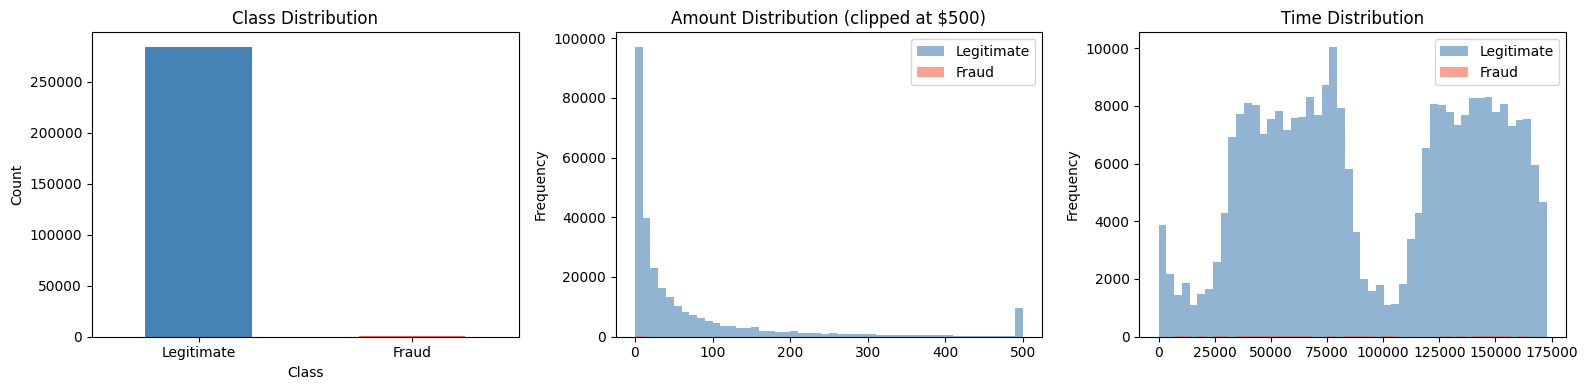

Amount median: $22.00 | max: $25691.16 | skew: 16.98


In [17]:

# ============================================================
# Exploratory Data Analysis
# ============================================================

# Trying to evaluate the fraud vs legitimate transaction count
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[0].set_ylabel('Count')

# This is for the histogram
df[df['Class']==0]['Amount'].clip(upper=500).plot(
    kind='hist', bins=50, ax=axes[1], alpha=0.6, label='Legitimate', color='steelblue')
df[df['Class']==1]['Amount'].clip(upper=500).plot(
    kind='hist', bins=50, ax=axes[1], alpha=0.6, label='Fraud', color='tomato')
axes[1].set_title('Amount Distribution (clipped at $500)')
axes[1].legend()
 # This is for the time distribution
df[df['Class']==0]['Time'].plot(
    kind='hist', bins=50, ax=axes[2], alpha=0.6, label='Legitimate', color='steelblue')
df[df['Class']==1]['Time'].plot(
    kind='hist', bins=50, ax=axes[2], alpha=0.6, label='Fraud', color='tomato')
axes[2].set_title('Time Distribution')
axes[2].legend()
# Combination layout


plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

print(f"Amount median: ${df['Amount'].median():.2f} | max: ${df['Amount'].max():.2f} | skew: {df['Amount'].skew():.2f}")


In [18]:
# ============================================================
# Preprocessing
# ============================================================
# Handle missing values
df.dropna(inplace=True)

X = df.drop(columns=['Class'])
y = df['Class']

X = df.drop(columns=['Class']).values
y = df['Class'].values
feature_names = df.drop(columns=['Class']).columns.tolist()




In [19]:
print("Change 1: 5-fold stratified CV replaces the single 80/20 split")
print(" The entire pipeline (scaling, class weights, threshold tuning) is")
print("fitted inside each fold — this gives honest variance estimates")
print("and eliminates pseudoreplication from a single lucky/unlucky split")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Change 2: Formalised threshold selection")
print("Search 0.01 to 0.99 in steps of 0.01 (99 candidates)")
print("Done independently per model, per fold, on val data only — never on test")
def find_best_threshold(y_val, y_probs):
    best_t, best_f1 = 0.5, 0
    for t in np.arange(0.01, 1.00, 0.01):
        f1 = f1_score(y_val, (y_probs >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t



In [20]:

# ============================================================
# Preprocessing and evaluation
# ============================================================
def evaluate(name, y_true, y_probs, threshold):
    y_preds = (y_probs >= threshold).astype(int)
    return {
        'Model':     name,
        'AUPRC':     round(average_precision_score(y_true, y_probs), 4),
        'AUROC':     round(roc_auc_score(y_true, y_probs), 4),
        'F1':        round(f1_score(y_true, y_preds, zero_division=0), 4),
        'Precision': round(precision_score(y_true, y_preds, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_preds), 4),
        'Threshold': round(threshold, 3),
    }

def print_summary(name, results):
    df_r = pd.DataFrame(results)
    print(f"\n{name} — Mean ± Std across 5 folds:")
    for col in ['AUPRC','AUROC','F1','Precision','Recall','Threshold']:
        print(f"  {col:10s}: {df_r[col].mean():.4f} ± {df_r[col].std():.4f}")
    return df_r

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nRunning on: {device}")
print(f"Starting 5-fold cross-validation...\n")

# --- Temporal split (60% train / 20% val / 20% test) ---
# I'm sorting by time first so the split is chronological
# This is important because a random split could leak fraud patterns
# that happen in the same time window across train and test
df_sorted = df.sort_values('Time').reset_index(drop=True)
n = len(df_sorted)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

X_train = df_sorted.iloc[:train_end].drop(columns=['Class']).copy()
y_train = df_sorted.iloc[:train_end]['Class']
X_val   = df_sorted.iloc[train_end:val_end].drop(columns=['Class']).copy()
y_val   = df_sorted.iloc[train_end:val_end]['Class']
X_test  = df_sorted.iloc[val_end:].drop(columns=['Class']).copy()
y_test  = df_sorted.iloc[val_end:]['Class']

print(f"Train: {len(X_train):,} samples | Fraud: {y_train.sum()}")
print(f"Val:   {len(X_val):,}   samples | Fraud: {y_val.sum()}")
print(f"Test:  {len(X_test):,}  samples | Fraud: {y_test.sum()}")



Running on: cuda
Starting 5-fold cross-validation...

Train: 170,884 samples | Fraud: 360
Val:   56,961   samples | Fraud: 57
Test:  56,962  samples | Fraud: 75


In [21]:

# ============================================================
# METHOD 1: Logistic Regression (Linear Baseline)
# ============================================================
print("\n" + "="*55)
print("METHOD 1: Logistic Regression (Linear Baseline)")
print("="*55)

# Starting with logistic regression as the simplest possible baseline
# This helps us understand how much the more complex models actually add

lr_results  = []
lr_all_probs, lr_all_true = [], []

for fold, (train_val_idx, test_idx) in enumerate(skf.split(X, y)):
    X_tv, y_tv = X[train_val_idx], y[train_val_idx]
    X_te, y_te = X[test_idx],      y[test_idx]

    # Inner val split for threshold tuning (75/25 of train_val)
    inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=fold)
    tr_idx, vl_idx = next(inner.split(X_tv, y_tv))
    X_tr, y_tr = X_tv[tr_idx], y_tv[tr_idx]
    X_vl, y_vl = X_tv[vl_idx], y_tv[vl_idx]

    # Fit RobustScaler on train only — applied to val and test
    scaler = RobustScaler()
    X_tr_s, X_vl_s, X_te_s = X_tr.copy(), X_vl.copy(), X_te.copy()
    X_tr_s[:, [-2,-1]] = scaler.fit_transform(X_tr[:, [-2,-1]])
    X_vl_s[:, [-2,-1]] = scaler.transform(X_vl[:, [-2,-1]])
    X_te_s[:, [-2,-1]] = scaler.transform(X_te[:, [-2,-1]])

    lr = LogisticRegression(C=1.0, class_weight='balanced',
                            max_iter=1000, random_state=42)
    lr.fit(X_tr_s, y_tr)

    vp = lr.predict_proba(X_vl_s)[:, 1]
    tp = lr.predict_proba(X_te_s)[:, 1]
    t  = find_best_threshold(y_vl, vp)   # threshold from val only

    lr_results.append(evaluate('Logistic Regression', y_te, tp, t))
    lr_all_probs.extend(tp)
    lr_all_true.extend(y_te)
    print(f"  Fold {fold+1}: AUPRC={lr_results[-1]['AUPRC']:.4f} | F1={lr_results[-1]['F1']:.4f} | Threshold={t:.2f}")

lr_df = print_summary('Logistic Regression', lr_results)
print(f"\n{classification_report(lr_all_true, (np.array(lr_all_probs) >= lr_df['Threshold'].mean()).astype(int), target_names=['Legit','Fraud'])}")




METHOD 1: Logistic Regression (Linear Baseline)
  Fold 1: AUPRC=0.7017 | F1=0.6838 | Threshold=0.99
  Fold 2: AUPRC=0.7071 | F1=0.7210 | Threshold=0.99
  Fold 3: AUPRC=0.7208 | F1=0.7074 | Threshold=0.99
  Fold 4: AUPRC=0.7693 | F1=0.7085 | Threshold=0.99
  Fold 5: AUPRC=0.7115 | F1=0.6721 | Threshold=0.99

Logistic Regression — Mean ± Std across 5 folds:
  AUPRC     : 0.7221 ± 0.0273
  AUROC     : 0.9782 ± 0.0099
  F1        : 0.6986 ± 0.0200
  Precision : 0.6063 ± 0.0292
  Recall    : 0.8252 ± 0.0183
  Threshold : 0.9900 ± 0.0000

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    284315
       Fraud       0.61      0.83      0.70       492

    accuracy                           1.00    284807
   macro avg       0.80      0.91      0.85    284807
weighted avg       1.00      1.00      1.00    284807



In [22]:

# ============================================================
# METHOD 2: Random Forest
# ============================================================
print("\n" + "="*55)
print("METHOD 2: Random Forest")
print("="*55)


rf_results = []
rf_all_probs, rf_all_true = [], []
rf_final_importances = np.zeros(X.shape[1])  # accumulate across folds

for fold, (train_val_idx, test_idx) in enumerate(skf.split(X, y)):
    X_tv, y_tv = X[train_val_idx], y[train_val_idx]
    X_te, y_te = X[test_idx],      y[test_idx]

    inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=fold)
    tr_idx, vl_idx = next(inner.split(X_tv, y_tv))
    X_tr, y_tr = X_tv[tr_idx], y_tv[tr_idx]
    X_vl, y_vl = X_tv[vl_idx], y_tv[vl_idx]

    scaler = RobustScaler()
    X_tr_s, X_vl_s, X_te_s = X_tr.copy(), X_vl.copy(), X_te.copy()
    X_tr_s[:, [-2,-1]] = scaler.fit_transform(X_tr[:, [-2,-1]])
    X_vl_s[:, [-2,-1]] = scaler.transform(X_vl[:, [-2,-1]])
    X_te_s[:, [-2,-1]] = scaler.transform(X_te[:, [-2,-1]])

    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                random_state=42, n_jobs=-1)
    rf.fit(X_tr_s, y_tr)
    rf_final_importances += rf.feature_importances_  # accumulate

    vp = rf.predict_proba(X_vl_s)[:, 1]
    tp = rf.predict_proba(X_te_s)[:, 1]
    t  = find_best_threshold(y_vl, vp)

    rf_results.append(evaluate('Random Forest', y_te, tp, t))
    rf_all_probs.extend(tp)
    rf_all_true.extend(y_te)
    print(f"  Fold {fold+1}: AUPRC={rf_results[-1]['AUPRC']:.4f} | F1={rf_results[-1]['F1']:.4f} | Threshold={t:.2f}")

rf_df = print_summary('Random Forest', rf_results)
print(f"\n{classification_report(rf_all_true, (np.array(rf_all_probs) >= rf_df['Threshold'].mean()).astype(int), target_names=['Legit','Fraud'])}")





METHOD 2: Random Forest
  Fold 1: AUPRC=0.8274 | F1=0.8144 | Threshold=0.17
  Fold 2: AUPRC=0.8879 | F1=0.8821 | Threshold=0.13
  Fold 3: AUPRC=0.8547 | F1=0.9022 | Threshold=0.29
  Fold 4: AUPRC=0.8448 | F1=0.8409 | Threshold=0.44
  Fold 5: AUPRC=0.8129 | F1=0.8587 | Threshold=0.29

Random Forest — Mean ± Std across 5 folds:
  AUPRC     : 0.8455 ± 0.0286
  AUROC     : 0.9528 ± 0.0037
  F1        : 0.8597 ± 0.0343
  Precision : 0.9120 ± 0.0523
  Recall    : 0.8150 ± 0.0443
  Threshold : 0.2640 ± 0.1216

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    284315
       Fraud       0.92      0.82      0.87       492

    accuracy                           1.00    284807
   macro avg       0.96      0.91      0.93    284807
weighted avg       1.00      1.00      1.00    284807



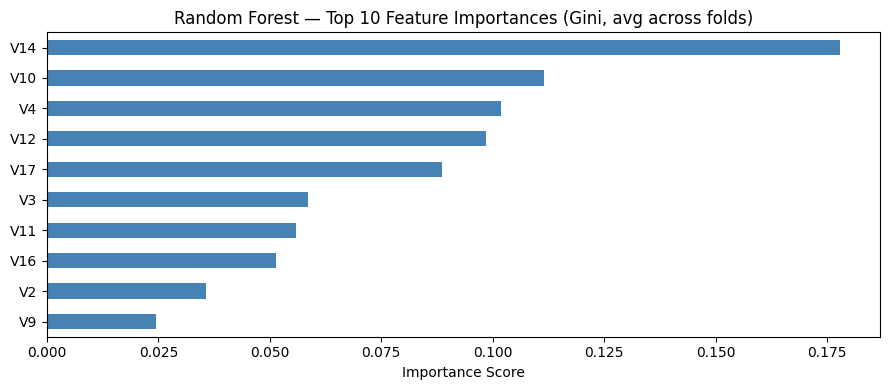

Top 5 features: ['V14', 'V10', 'V4', 'V12', 'V17']


In [24]:
# Feature importance averaged across folds
feat_imp = pd.Series(rf_final_importances / 5, index=feature_names)
top10 = feat_imp.nlargest(10)
plt.figure(figsize=(9, 4))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.title('Random Forest — Top 10 Feature Importances (Gini, avg across folds)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()
print(f"Top 5 features: {list(top10.head().index)}")



In [23]:

# ============================================================
# METHOD 3: XGBoost
# ============================================================
print("\n" + "="*55)
print("METHOD 3: XGBoost")
print("="*55)

xgb_results = []
xgb_all_probs, xgb_all_true = [], []

for fold, (train_val_idx, test_idx) in enumerate(skf.split(X, y)):
    X_tv, y_tv = X[train_val_idx], y[train_val_idx]
    X_te, y_te = X[test_idx],      y[test_idx]

    inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=fold)
    tr_idx, vl_idx = next(inner.split(X_tv, y_tv))
    X_tr, y_tr = X_tv[tr_idx], y_tv[tr_idx]
    X_vl, y_vl = X_tv[vl_idx], y_tv[vl_idx]

    scaler = RobustScaler()
    X_tr_s, X_vl_s, X_te_s = X_tr.copy(), X_vl.copy(), X_te.copy()
    X_tr_s[:, [-2,-1]] = scaler.fit_transform(X_tr[:, [-2,-1]])
    X_vl_s[:, [-2,-1]] = scaler.transform(X_vl[:, [-2,-1]])
    X_te_s[:, [-2,-1]] = scaler.transform(X_te[:, [-2,-1]])

    n_legit = (y_tr == 0).sum()
    n_fraud = (y_tr == 1).sum()

    xgb = XGBClassifier(
        scale_pos_weight = n_legit / n_fraud,
        n_estimators=100, learning_rate=0.1,
        max_depth=6, random_state=42,
        eval_metric='aucpr', verbosity=0
    )
    xgb.fit(X_tr_s, y_tr, eval_set=[(X_vl_s, y_vl)], verbose=False)

    vp = xgb.predict_proba(X_vl_s)[:, 1]
    tp = xgb.predict_proba(X_te_s)[:, 1]
    t  = find_best_threshold(y_vl, vp)

    xgb_results.append(evaluate('XGBoost', y_te, tp, t))
    xgb_all_probs.extend(tp)
    xgb_all_true.extend(y_te)
    print(f"  Fold {fold+1}: AUPRC={xgb_results[-1]['AUPRC']:.4f} | F1={xgb_results[-1]['F1']:.4f} | Threshold={t:.2f}")

xgb_df = print_summary('XGBoost', xgb_results)
print(f"\n{classification_report(xgb_all_true, (np.array(xgb_all_probs) >= xgb_df['Threshold'].mean()).astype(int), target_names=['Legit','Fraud'])}")




METHOD 3: XGBoost
  Fold 1: AUPRC=0.8216 | F1=0.8021 | Threshold=0.81
  Fold 2: AUPRC=0.8714 | F1=0.8729 | Threshold=0.96
  Fold 3: AUPRC=0.8447 | F1=0.8778 | Threshold=0.96
  Fold 4: AUPRC=0.8422 | F1=0.8571 | Threshold=0.88
  Fold 5: AUPRC=0.7970 | F1=0.8352 | Threshold=0.96

XGBoost — Mean ± Std across 5 folds:
  AUPRC     : 0.8354 ± 0.0278
  AUROC     : 0.9748 ± 0.0128
  F1        : 0.8490 ± 0.0310
  Precision : 0.9225 ± 0.0464
  Recall    : 0.7866 ± 0.0198
  Threshold : 0.9140 ± 0.0677

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    284315
       Fraud       0.92      0.79      0.85       492

    accuracy                           1.00    284807
   macro avg       0.96      0.90      0.92    284807
weighted avg       1.00      1.00      1.00    284807



In [25]:
# ============================================================
# METHOD 4: MLP (Deep Learning) with 5-Seed Evaluation
# ============================================================
print("\n" + "="*55)
print("METHOD 4: MLP (Deep Learning) — 5 Seeds")
print("="*55)
print("Our main deep learning contribution — 30→64→32→1")
print("Weighted BCE loss with pos_weight = w1/w0 (~578).\n")

class FraudMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

mlp_results = []
mlp_all_probs, mlp_all_true = [], []

for fold, (train_val_idx, test_idx) in enumerate(skf.split(X, y)):
    X_tv, y_tv = X[train_val_idx], y[train_val_idx]
    X_te, y_te = X[test_idx],      y[test_idx]

    inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=fold)
    tr_idx, vl_idx = next(inner.split(X_tv, y_tv))
    X_tr, y_tr = X_tv[tr_idx], y_tv[tr_idx]
    X_vl, y_vl = X_tv[vl_idx], y_tv[vl_idx]

    scaler = RobustScaler()
    X_tr_s, X_vl_s, X_te_s = X_tr.copy(), X_vl.copy(), X_te.copy()
    X_tr_s[:, [-2,-1]] = scaler.fit_transform(X_tr[:, [-2,-1]])
    X_vl_s[:, [-2,-1]] = scaler.transform(X_vl[:, [-2,-1]])
    X_te_s[:, [-2,-1]] = scaler.transform(X_te[:, [-2,-1]])

    n_legit = (y_tr == 0).sum()
    n_fraud = (y_tr == 1).sum()
    pos_weight = torch.tensor([n_legit / n_fraud], dtype=torch.float32).to(device)

    # Average over multiple seeds per fold for stability
    fold_probs = []
    for seed in SEEDS:
        torch.manual_seed(seed)
        model     = FraudMLP(X_tr_s.shape[1]).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        loader    = DataLoader(TensorDataset(
            torch.tensor(X_tr_s, dtype=torch.float32),
            torch.tensor(y_tr,   dtype=torch.float32).unsqueeze(1)
        ), batch_size=256, shuffle=True)

        best_f1, best_state, patience_count = 0, None, 0
        Xv_t = torch.tensor(X_vl_s, dtype=torch.float32).to(device)

        for epoch in range(50):
            model.train()
            for xb, yb in loader:
                optimizer.zero_grad()
                criterion(model(xb.to(device)), yb.to(device)).backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                vp = 1/(1+np.exp(-model(Xv_t).cpu().numpy().flatten()))

            t  = find_best_threshold(y_vl, vp)
            vf = f1_score(y_vl, (vp >= t).astype(int), zero_division=0)

            if vf > best_f1:
                best_f1    = vf
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                patience_count = 0
            else:
                patience_count += 1
                if patience_count >= 5:
                    break

        model.load_state_dict(best_state)
        model.eval()
        Xt_t = torch.tensor(X_te_s, dtype=torch.float32).to(device)
        with torch.no_grad():
            tp = 1/(1+np.exp(-model(Xt_t).cpu().numpy().flatten()))
        fold_probs.append(tp)

    # Average predictions across seeds then tune threshold on val
    avg_probs = np.mean(fold_probs, axis=0)
    Xv_t = torch.tensor(X_vl_s, dtype=torch.float32).to(device)

    # Get val probs from last seed model for threshold tuning
    model.eval()
    with torch.no_grad():
        vp_final = 1/(1+np.exp(-model(Xv_t).cpu().numpy().flatten()))
    t_final = find_best_threshold(y_vl, vp_final)

    mlp_results.append(evaluate('MLP', y_te, avg_probs, t_final))
    mlp_all_probs.extend(avg_probs)
    mlp_all_true.extend(y_te)
    print(f"  Fold {fold+1}: AUPRC={mlp_results[-1]['AUPRC']:.4f} | F1={mlp_results[-1]['F1']:.4f} | Threshold={t_final:.2f}")

mlp_df = print_summary('MLP', mlp_results)
print(f"\n{classification_report(mlp_all_true, (np.array(mlp_all_probs) >= mlp_df['Threshold'].mean()).astype(int), target_names=['Legit','Fraud'])}")





METHOD 4: MLP (Deep Learning) — 5 Seeds
Our main deep learning contribution — 30→64→32→1
Weighted BCE loss with pos_weight = w1/w0 (~578).

  Fold 1: AUPRC=0.5990 | F1=0.5984 | Threshold=0.53
  Fold 2: AUPRC=0.7114 | F1=0.4930 | Threshold=0.65
  Fold 3: AUPRC=0.5339 | F1=0.0115 | Threshold=0.47
  Fold 4: AUPRC=0.3870 | F1=0.2931 | Threshold=0.69
  Fold 5: AUPRC=0.6450 | F1=0.3810 | Threshold=0.70

MLP — Mean ± Std across 5 folds:
  AUPRC     : 0.5753 ± 0.1236
  AUROC     : 0.9065 ± 0.0325
  F1        : 0.3554 ± 0.2240
  Precision : 0.6223 ± 0.3851
  Recall    : 0.4630 ± 0.2889
  Threshold : 0.6080 ± 0.1026

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    284315
       Fraud       0.16      0.45      0.23       492

    accuracy                           0.99    284807
   macro avg       0.58      0.72      0.62    284807
weighted avg       1.00      0.99      1.00    284807



In [26]:
#  ============================================================
# MLP Depth Ablation
# ============================================================
print("Testing whether more layers meaningfully improve AUPRC.")
print("Hypothesis: 2 layers is sufficient for this dataset.\n")

def build_mlp(layers, input_dim):
    blocks, in_d = [], input_dim
    for out_d in layers:
        blocks += [nn.Linear(in_d, out_d), nn.BatchNorm1d(out_d),
                   nn.ReLU(), nn.Dropout(0.3)]
        in_d = out_d
    blocks.append(nn.Linear(in_d, 1))
    return nn.Sequential(*blocks)

depth_configs = {
    '1 Layer  (64)':        [64],
    '2 Layers (64,32)':     [64, 32],
    '3 Layers (128,64,32)': [128, 64, 32],
}

for config_name, layers in depth_configs.items():
    auprcs = []
    for seed in SEEDS:
        torch.manual_seed(seed)
        m   = build_mlp(layers, X.shape[1]).to(device)
        opt = torch.optim.Adam(m.parameters(), lr=1e-3)
        crt = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([578.0]).to(device))
        Xtr = torch.tensor(X[:170000], dtype=torch.float32)
        ytr = torch.tensor(y[:170000], dtype=torch.float32).unsqueeze(1)
        dl  = DataLoader(TensorDataset(Xtr, ytr), batch_size=256, shuffle=True)
        for _ in range(20):
            m.train()
            for xb, yb in dl:
                opt.zero_grad()
                crt(m(xb.to(device)), yb.to(device)).backward()
                opt.step()
        m.eval()
        Xte = torch.tensor(X[170000:], dtype=torch.float32).to(device)
        with torch.no_grad():
            tp = 1/(1+np.exp(-m(Xte).cpu().numpy().flatten()))
        auprcs.append(average_precision_score(y[170000:], tp))
    print(f"  {config_name}: {np.mean(auprcs):.4f} ± {np.std(auprcs):.4f}")



Testing whether more layers meaningfully improve AUPRC.
Hypothesis: 2 layers is sufficient for this dataset.

  1 Layer  (64): 0.2741 ± 0.1981
  2 Layers (64,32): 0.5689 ± 0.1919
  3 Layers (128,64,32): 0.2703 ± 0.1685



Threshold Sensitivity — Random Forest (Pooled CV)
Optimal threshold: 0.26 | F1=0.8700
As expected, optimal threshold << 0.5 because fraud is rare (0.172%)


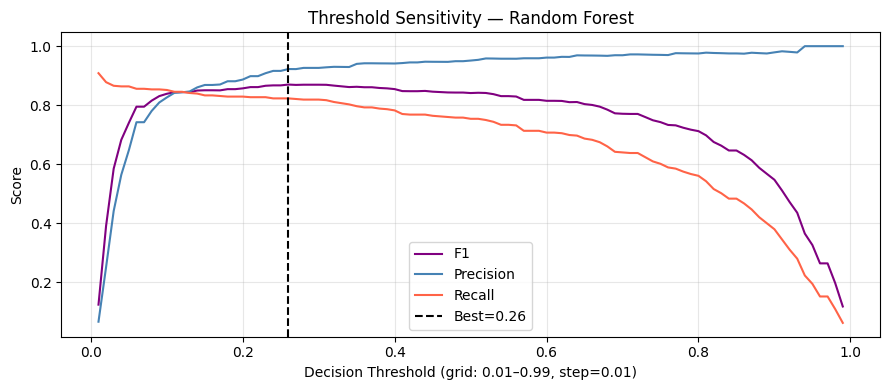

In [27]:
# ============================================================
# ABLATION: Threshold Sensitivity
# ============================================================
print("\n" + "=" * 55)
print("Threshold Sensitivity — Random Forest (Pooled CV)")
print("=" * 55)

thresholds   = np.arange(0.01, 1.00, 0.01)
rf_probs_arr = np.array(rf_all_probs)
rf_true_arr  = np.array(rf_all_true)

t_f1s  = [f1_score(rf_true_arr,  (rf_probs_arr>=t).astype(int), zero_division=0) for t in thresholds]
t_prec = [precision_score(rf_true_arr, (rf_probs_arr>=t).astype(int), zero_division=0) for t in thresholds]
t_rec  = [recall_score(rf_true_arr, (rf_probs_arr>=t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(t_f1s)]

print(f"Optimal threshold: {best_t:.2f} | F1={max(t_f1s):.4f}")
print("As expected, optimal threshold << 0.5 because fraud is rare (0.172%)")

plt.figure(figsize=(9, 4))
plt.plot(thresholds, t_f1s,  label='F1',       color='purple')
plt.plot(thresholds, t_prec, label='Precision', color='steelblue')
plt.plot(thresholds, t_rec,  label='Recall',    color='tomato')
plt.axvline(best_t, color='black', linestyle='--', label=f'Best={best_t:.2f}')
plt.xlabel('Decision Threshold (grid: 0.01–0.99, step=0.01)')
plt.ylabel('Score')
plt.title('Threshold Sensitivity — Random Forest')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_sensitivity.png', dpi=150)
plt.show()

FINAL: Head-to-Head Comparison — All Models
              Model           AUPRC              F1       Precision          Recall   Threshold
Logistic Regression 0.7221 ± 0.0273 0.6986 ± 0.0200 0.6063 ± 0.0292 0.8252 ± 0.0183 0.99 ± 0.00
      Random Forest 0.8455 ± 0.0286 0.8597 ± 0.0343 0.9120 ± 0.0523 0.8150 ± 0.0443 0.26 ± 0.12
            XGBoost 0.8354 ± 0.0278 0.8490 ± 0.0310 0.9225 ± 0.0464 0.7866 ± 0.0198 0.91 ± 0.07
                MLP 0.5753 ± 0.1236 0.3554 ± 0.2240 0.6223 ± 0.3851 0.4630 ± 0.2889 0.61 ± 0.10


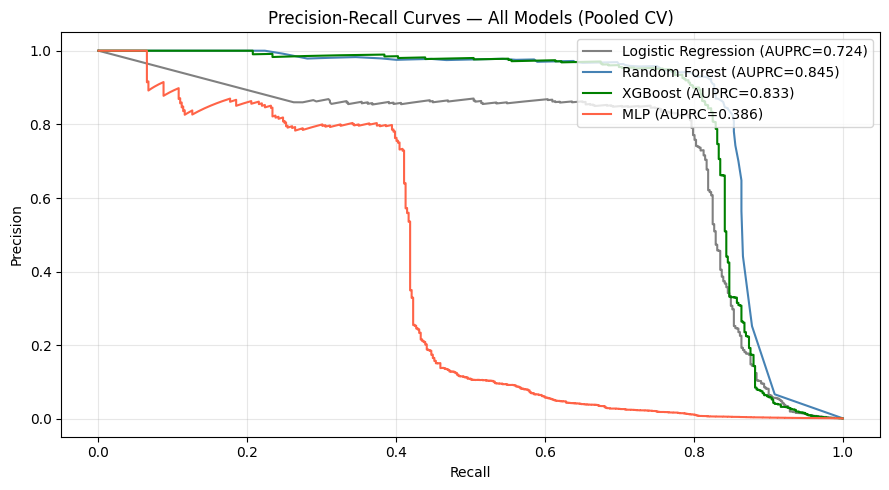

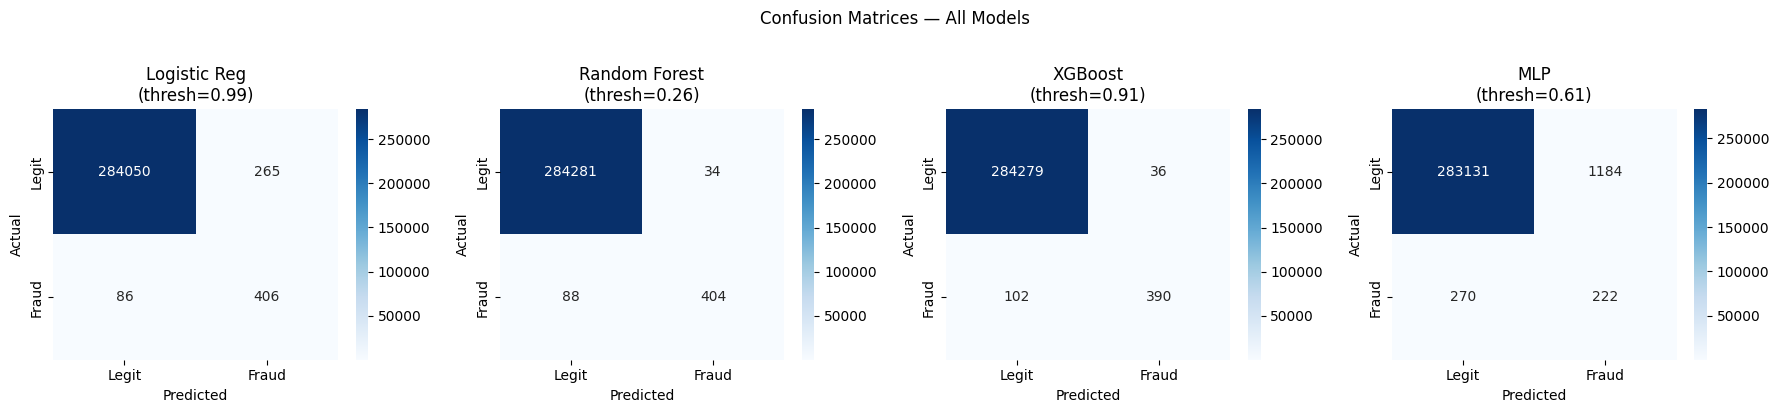

In [28]:
# ============================================================
# Final Comparison Table + PR Curves + Confusion Matrices
# ============================================================
print("=" * 55)
print("FINAL: Head-to-Head Comparison — All Models")
print("=" * 55)

summary_rows = []
for name, df_r in [('Logistic Regression', lr_df),
                   ('Random Forest',       rf_df),
                   ('XGBoost',             xgb_df),
                   ('MLP',                 mlp_df)]:
    summary_rows.append({
        'Model':     name,
        'AUPRC':     f"{df_r['AUPRC'].mean():.4f} ± {df_r['AUPRC'].std():.4f}",
        'F1':        f"{df_r['F1'].mean():.4f} ± {df_r['F1'].std():.4f}",
        'Precision': f"{df_r['Precision'].mean():.4f} ± {df_r['Precision'].std():.4f}",
        'Recall':    f"{df_r['Recall'].mean():.4f} ± {df_r['Recall'].std():.4f}",
        'Threshold': f"{df_r['Threshold'].mean():.2f} ± {df_r['Threshold'].std():.2f}",
    })
print(pd.DataFrame(summary_rows).to_string(index=False))

# PR Curves
plt.figure(figsize=(9, 5))
for probs, true, name, color in [
    (lr_all_probs,  lr_all_true,  'Logistic Regression', 'gray'),
    (rf_all_probs,  rf_all_true,  'Random Forest',       'steelblue'),
    (xgb_all_probs, xgb_all_true, 'XGBoost',             'green'),
    (mlp_all_probs, mlp_all_true, 'MLP',                 'tomato'),
]:
    p, r, _ = precision_recall_curve(true, probs)
    auprc   = average_precision_score(true, probs)
    plt.plot(r, p, label=f'{name} (AUPRC={auprc:.3f})', color=color)

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curves — All Models (Pooled CV)')
plt.legend(loc='upper right'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150)
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, probs, true, df_r, name in zip(
    axes,
    [lr_all_probs, rf_all_probs, xgb_all_probs, mlp_all_probs],
    [lr_all_true,  rf_all_true,  xgb_all_true,  mlp_all_true],
    [lr_df, rf_df, xgb_df, mlp_df],
    ['Logistic Reg', 'Random Forest', 'XGBoost', 'MLP']
):
    t  = df_r['Threshold'].mean()
    cm = confusion_matrix(true, (np.array(probs) >= t).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit','Fraud'],
                yticklabels=['Legit','Fraud'])
    ax.set_title(f'{name}\n(thresh={t:.2f})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
plt.show()


Class-weighted training distorts predicted probabilities.
A well-calibrated model: predicted 0.7 → ~70% are actually fraud.
Poor calibration means threshold decisions may not be reliable
even if AUPRC looks high.

Logistic Regression    — Mean Calibration Error: 0.4715
Random Forest          — Mean Calibration Error: 0.1529
XGBoost                — Mean Calibration Error: 0.2940
MLP                    — Mean Calibration Error: 0.3337


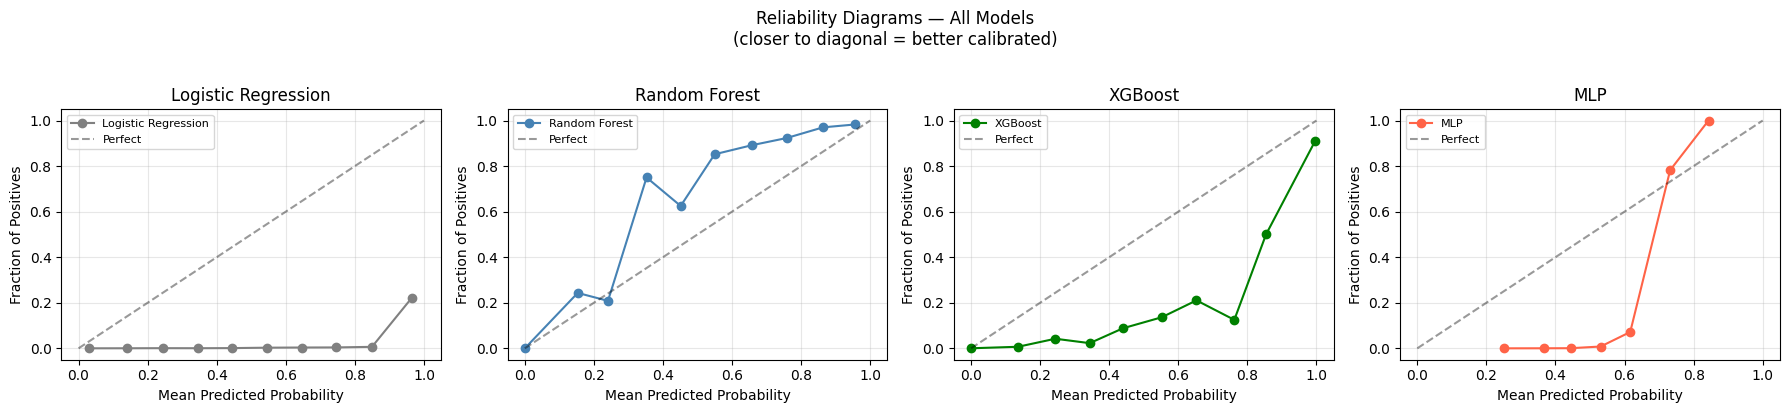

In [29]:
# ============================================================
# Calibration (Reliability Diagrams)
#
# CHANGE 3: Added calibration plots for all models
# Class-weighted training distorts predicted probabilities.
# A well-calibrated model: predicted prob 0.7 → ~70% of those
# are actually fraud. Poor calibration means threshold-based
# decisions may not be reliable even if AUPRC is high.
# ============================================================
print("CHANGE 3: Class-weighted training distorts predicted probabilities.")
print("A well-calibrated model: predicted 0.7 → ~70% are actually fraud.")
print("Poor calibration means threshold decisions may not be reliable")
print("even if AUPRC looks high.\n")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, probs, true, name, color in zip(
    axes,
    [lr_all_probs, rf_all_probs, xgb_all_probs, mlp_all_probs],
    [lr_all_true,  rf_all_true,  xgb_all_true,  mlp_all_true],
    ['Logistic Regression', 'Random Forest', 'XGBoost', 'MLP'],
    ['gray', 'steelblue', 'green', 'tomato']
):
    frac_pos, mean_pred = calibration_curve(true, probs, n_bins=10, strategy='uniform')
    ax.plot(mean_pred, frac_pos, marker='o', color=color, label=name)
    ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Perfect')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(name); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    cal_error = np.mean(np.abs(frac_pos - mean_pred))
    print(f"{name:22s} — Mean Calibration Error: {cal_error:.4f}")

plt.suptitle('Reliability Diagrams — All Models\n(closer to diagonal = better calibrated)', y=1.02)
plt.tight_layout()
plt.savefig('calibration_plots.png', dpi=150)
plt.show()
